In [96]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

## training a VAE

In [97]:
import torch
import rdkit
from rdkit import Chem
print(torch.__version__)
print(Chem.MolFromSmiles("CCO"))

2.11.0


In [98]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
df = data.get_data()
print(df.shape)
df.head()

Found local copy...
Loading...
Done!


(13130, 3)


,Drug_ID,Drug,Y
0,1960010.0,CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21,0
1,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,0
2,644890.0,COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1,1
3,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0
4,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0


## building the character vocabulary
we start off by building the character vocabulary, since a VAE encodes smiles strings into a latent vector. a neural network cant take raw text - only numbers, so we convert each character in a smiles string to an integer.

`<pad>` - used to make all SMILES the same length in a batch (token = 0)

`<sos>` - start of sequence, tells the decoder to begin generating (token = 1)

`<eos>` - end of sequence, tells the decoder to stop (token = 2)

!!!! this can raise an issue because neural networks care abt what the numbers mean - check the thing with 0 and 1s (one hot encodding)

In [99]:
smiles_list = df['Drug'].tolist()

vocab = sorted(set(''.join(smiles_list)))
vocab = ['<pad>', '<sos>', '<eos>'] + vocab

char2idx = {ch: idx for idx, ch in enumerate(vocab)} # given a character, return its index
idx2char = {idx: ch for ch, idx in char2idx.items()} # given an index, return its character

print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

Vocabulary size: 55
Characters: ['<pad>', '<sos>', '<eos>', '#', '%', '(', ')', '+', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'W', 'Z', '[', '\\', ']', 'a', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 't', 'u']


Next step is to check the distribution of SMILES lengths to configure padding

Max length: 402
Mean length: 46.1
95th percentile: 84


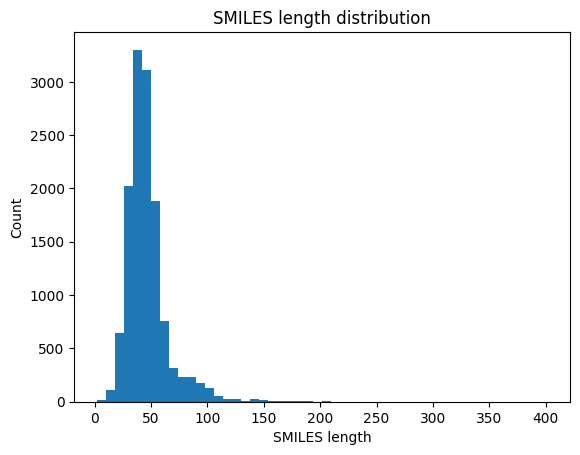

In [100]:
import matplotlib.pyplot as plt

lengths = [len(s) for s in smiles_list]
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95*len(lengths))]}")

plt.hist(lengths, bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("SMILES length distribution")
plt.show()

the distribution is right-skewed, with a mean length of smiles strings being 46.1 (small molecules) and the 95th percentile is 85, so we set `max_length` = 100

## Tokenization and Encoding of SMILES 

In [101]:
import torch

MAX_LENGTH = 100

def encode_smiles(smiles, char2idx, max_length):
    """
    Convert a SMILES string to a fixed-length integer sequence.
    
    Wraps the sequence with <sos> and <eos> tokens, truncates sequences
    longer than max_length, and pads shorter sequences with <pad> tokens.
    
    Args:
        smiles (str): SMILES string of a molecule.
        char2idx (dict): mapping from character to integer index.
        max_length (int): fixed length for all output sequences.
    
    Returns:
        list[int]: integer-encoded sequence of length max_length.
    """
    tokens = ['<sos>'] + list(smiles) + ['<eos>']
    tokens = tokens[:max_length]
    tokens += ['<pad>'] * (max_length - len(tokens))
    return [char2idx[t] for t in tokens]


In [102]:
# Test on one SMILES
example = smiles_list[0]
encoded = encode_smiles(example, char2idx, MAX_LENGTH)
print(f"SMILES: {example}")
print(f"Encoded: {encoded}")
print(f"Length: {len(encoded)}")

SMILES: CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21
Encoded: [1, 25, 25, 32, 12, 25, 5, 21, 33, 6, 10, 25, 5, 21, 25, 13, 40, 36, 25, 5, 21, 36, 6, 32, 5, 25, 25, 25, 33, 25, 6, 25, 13, 21, 33, 6, 44, 13, 44, 44, 44, 44, 44, 13, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 100


In [103]:
# encode the entire dataset
encoded_data = [encode_smiles(s, char2idx, MAX_LENGTH) for s in smiles_list]
encoded_data = torch.tensor(encoded_data, dtype=torch.long)
print(encoded_data.shape)

torch.Size([13130, 100])


## build the pytorch dataset and dataloader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class SMILESDataset(Dataset):
    def __init__(self, encoded_data):
        self.data = encoded_data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

dataset = SMILESDataset(encoded_data)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True) # check the batch size again 

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Dataset size: 13130
Number of batches: 52


## VAE Model

The VAE consists of three components:
- **Encoder** (MLP): flattens the one-hot SMILES sequence and compresses it to a latent distribution via two linear layers
- **Reparameterisation**: samples from the latent distribution while keeping the computation graph differentiable
- **Decoder** (GRU): reconstructs the SMILES sequence autoregressively from the latent vector

In [105]:
import torch.nn as nn
import torch.nn.functional as F


class Encoder(nn.Module):
    """
    Encodes a tokenised SMILES sequence into a latent distribution (mu, log_var)
    using two 1D convolutional layers followed by a fully-connected projection.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed length of the input sequence (MAX_LENGTH).
        hidden_dim (int): width of the fully-connected layer after flattening.
        latent_dim (int): dimension of the latent space.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv = nn.Sequential(
            nn.Conv1d(vocab_size, 128, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.Tanh(),
        )
        self.fc = nn.Linear(256 * seq_len, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch of shape (batch_size, seq_len).

        Returns:
            mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
        """
        embedded = F.one_hot(x, num_classes=self.vocab_size).float()  # (batch, seq_len, vocab_size)
        x_conv = embedded.permute(0, 2, 1)                            # (batch, vocab_size, seq_len)
        h = self.conv(x_conv)                                         # (batch, 256, seq_len)
        h = h.view(h.size(0), -1)                                     # (batch, 256 * seq_len)
        h = F.relu(self.fc(h))                                        # (batch, hidden_dim)
        return self.fc_mu(h), self.fc_logvar(h)

### Reparameterisation

The encoder outputs `mu` and `log_var`, which define a probability distribution in latent space.
We sample a latent vector `z` from this distribution using the reparameterisation trick.
This allows gradients to flow through the sampling step during backpropagation.

trick to make it differntiable

In [106]:
def reparameterise(mu, log_var):
    """
    Sample a latent vector z using the reparameterisation trick.
    
    Instead of sampling z directly from N(mu, std), we sample epsilon from N(0,1)
    and compute z = mu + epsilon * std. This keeps the sampling step differentiable.
    
    Args:
        mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
    
    Returns:
        z (Tensor): sampled latent vector, shape (batch_size, latent_dim).
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

### Decoder

The decoder takes the latent vector z and reconstructs the SMILES sequence token by token.
It uses a GRU that generates one token at a time, conditioned on z.

In [107]:
class Decoder(nn.Module):
    """
    Decodes a latent vector z into a SMILES sequence autoregressively.
    
    z is repeated across all timesteps via RepeatVector and concatenated
    with the one-hot token input at each step, so the GRU sees z at every
    timestep rather than only at initialisation. Hard teacher forcing is used
    during training.
    
    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        hidden_dim (int): hidden dimension of the GRU.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers.
    """
    def __init__(self, vocab_size, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.fc_z = nn.Linear(latent_dim, hidden_dim * n_layers)
        self.gru = nn.GRU(vocab_size + latent_dim, hidden_dim, n_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, z, x):
        """
        Args:
            z (Tensor): latent vector, shape (batch_size, latent_dim).
            x (Tensor): target sequence, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
        """
        hidden = self.fc_z(z)
        hidden = hidden.view(-1, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len = x.size(1) - 1
        x_onehot = F.one_hot(x[:, :-1], num_classes=self.vocab_size).float()  # (batch, seq_len-1, vocab_size)
        z_repeated = z.unsqueeze(1).expand(-1, seq_len, -1)                   # (batch, seq_len-1, latent_dim)
        gru_input = torch.cat([x_onehot, z_repeated], dim=-1)                 # (batch, seq_len-1, vocab_size + latent_dim)

        output, _ = self.gru(gru_input, hidden)
        logits = self.fc_out(output)
        return logits

In [108]:
class VAE(nn.Module):
    """
    Variational Autoencoder for SMILES strings.

    Combines the Encoder (MLP), reparameterisation trick, and Decoder (GRU) into
    a single model. The encoder compresses a flattened SMILES one-hot sequence into
    a latent distribution; a latent vector z is sampled via reparameterisation; the
    decoder reconstructs the sequence autoregressively from z.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed input sequence length passed to the MLP encoder.
        hidden_dim (int): hidden dimension for both encoder and decoder.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers in the decoder.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.encoder = Encoder(vocab_size, seq_len, hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, hidden_dim, latent_dim, n_layers)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
            mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        """
        mu, log_var = self.encoder(x)
        z = reparameterise(mu, log_var)
        logits = self.decoder(z, x)
        return logits, mu, log_var

In [109]:
VOCAB_SIZE = len(vocab)
HIDDEN_DIM = 512
LATENT_DIM = 256
N_LAYERS = 2

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(55, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=25600, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=256, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=256, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=256, out_features=1024, bias=True)
    (gru): GRU(311, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=55, bias=True)
  )
)
Total parameters: 16,624,695


In [110]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## Loss Function

The VAE loss has two components:
- Reconstruction loss: how well the decoder reconstructs the input SMILES
- KL divergence: how close the latent distribution is to a standard normal N(0,1)

Total loss = reconstruction loss + beta * KL divergence

In [ ]:
def vae_loss(logits, targets, mu, log_var, beta):
    """
    Compute the VAE loss: reconstruction loss + beta * KL divergence.
    
    Args:
        logits (Tensor): predicted token scores, shape (batch_size, seq_len, vocab_size).
        targets (Tensor): true token indices, shape (batch_size, seq_len).
        mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        beta (float): weight on the KL term, annealed from 0 to 1 during training.
    
    Returns:
        loss (Tensor): total VAE loss.
        recon_loss (Tensor): reconstruction loss component.
        kl_loss (Tensor): KL divergence component.
    """
    # Reconstruction loss
    recon_loss = nn.CrossEntropyLoss(ignore_index=0)(
    logits.view(-1, logits.size(-1)),
    targets.reshape(-1)
    )
    
    # KL divergence
    kl_free_bits = 0.5
    kl_loss = torch.clamp(-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()), min=kl_free_bits)  # free bits: prevent KL collapsing to 0

    
    loss = recon_loss + beta * kl_loss
    return loss, recon_loss, kl_loss

## Training Loop

We train the VAE for 50 epochs. Three stabilisation techniques are combined:

- **KL annealing**: beta ramps from 0 → 1 over the first 20 epochs, then stays at 1 for the remaining 30 epochs. Separating ANNEAL_EPOCHS from EPOCHS ensures the model trains for a sustained period under full regularisation — previously both were 30, so beta never actually reached 1.0 within the run.
- **Scheduled sampling**: epsilon decays 1.0 → 0.1, gradually weaning the decoder off teacher forcing.
- **ReduceLROnPlateau**: halves the learning rate when total loss plateaus, preventing oscillation late in training.

In [112]:
def evaluate(model, dataset, vocab_size, device, idx2char, n_samples=500):
    """
    Measure reconstruction accuracy and validity on a random subset of the dataset.

    Encodes n_samples real molecules to mu (no noise), decodes with teacher forcing
    and hard argmax, then reports exact sequence match rate and RDKit validity rate.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        logits = model.decoder(mu, batch)       # (n_samples, seq_len-1, vocab_size)
        pred_tokens = logits.argmax(dim=-1)     # (n_samples, seq_len-1)

    targets = batch[:, 1:]                      # (n_samples, seq_len-1)
    exact_acc = (pred_tokens == targets).all(dim=1).float().mean().item()

    valid_count = 0
    for seq in pred_tokens:
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        if smiles and Chem.MolFromSmiles(smiles) is not None:
            valid_count += 1
    validity = valid_count / n_samples

    return exact_acc, validity

In [113]:
import torch.optim as optim

EPOCHS = 50
BETA_MAX = 1.0
ANNEAL_EPOCHS = 20

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    total_grad_norm = 0

    beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits, mu, log_var = model(batch)
        loss, recon_loss, kl_loss = vae_loss(logits, batch[:, 1:], mu, log_var, beta)

        loss.backward()

        grad_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                grad_norm += p.grad.data.norm(2).item() ** 2
        total_grad_norm += grad_norm ** 0.5

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n_batches = len(dataloader)
    avg_loss = total_loss / n_batches
    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1:>2}/{EPOCHS}, beta: {beta:.2f} , "
          f"Loss: {avg_loss:.4f}  Recon: {total_recon/n_batches:.4f}  "
          f"KL: {total_kl/n_batches:.4f}  "
          f"Grad: {total_grad_norm/n_batches:.4f}  "
          f"LR: {optimizer.param_groups[0]['lr']:.1e}")

    exact_acc, validity = evaluate(model, dataset, VOCAB_SIZE, device, idx2char)
    print(f"         Recon acc: {exact_acc:.3f}  Validity: {validity:.3f}")

Epoch  1/50, beta: 0.00 , Loss: 2.5149  Recon: 2.5149  KL: 4.0358  Grad: 1.3726  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.072
Epoch  2/50, beta: 0.05 , Loss: 2.2631  Recon: 2.1096  KL: 3.0700  Grad: 2.1212  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.000
Epoch  3/50, beta: 0.10 , Loss: 1.8259  Recon: 1.5258  KL: 3.0009  Grad: 2.5922  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.000
Epoch  4/50, beta: 0.15 , Loss: 1.6043  Recon: 1.1541  KL: 3.0011  Grad: 2.2744  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.002
Epoch  5/50, beta: 0.20 , Loss: 1.5364  Recon: 0.9359  KL: 3.0025  Grad: 2.1408  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.008
Epoch  6/50, beta: 0.25 , Loss: 1.5146  Recon: 0.7644  KL: 3.0006  Grad: 1.7887  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.022
Epoch  7/50, beta: 0.30 , Loss: 1.5572  Recon: 0.6566  KL: 3.0020  Grad: 1.9076  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.026
Epoch  8/50, beta: 0.35 , Loss: 1.6267  Recon: 0

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'vae_trained4.pth')
print("Model saved")

Model saved


## Sampling evaluation

In [ ]:
from rdkit import Chem

def sample_molecules(model, num_samples, latent_dim, device, idx2char, max_length=100):
    """
    Sample molecules from the VAE using ancestral sampling.

    At each decoding step we draw the next token from the model's exact
    conditional distribution p(x_t | x_{1:t-1}, z) via multinomial sampling.
    z is concatenated to the one-hot input at every step to match the decoder
    architecture.
    """
    model.eval()
    sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        hidden = model.decoder.fc_z(z)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        input_token = torch.full((num_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(max_length):
            input_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()  # (batch, 1, vocab_size)
            z_step = z.unsqueeze(1)                                                    # (batch, 1, latent_dim)
            gru_input = torch.cat([input_onehot, z_step], dim=-1)                     # (batch, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))                          # (batch, vocab_size)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                      # (batch, 1)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)  # (batch, max_length)

        valid_smiles = []
        for seq in generated:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            valid_smiles.append(smiles)

    valid = [s for s in valid_smiles if Chem.MolFromSmiles(s) is not None]
    print(f"Sampled: {num_samples}")
    print(f"Valid SMILES: {len(valid)}")
    print(f"Validity rate: {len(valid)/num_samples*100:.1f}%")
    print("\nExamples:")
    for s in valid[:5]:
        print(s)

    return valid

valid_mols = sample_molecules(model, 100, LATENT_DIM, device, idx2char)

In [ ]:
for s in valid_mols[:10]:
    print(s)

OCS
